In [1]:
import pyomo.environ as pyo
import mpisppy.utils.sputils as sputils
from mpisppy.opt.ef import ExtensiveForm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Configuração para que os gráficos apareçam inline no Jupyter
%matplotlib inline

[    0.00] Initializing mpi-sppy


In [2]:
solver = pyo.SolverFactory('cplex')

# Configurações para 7 dias de operação
solver.options['emphasis_memory'] = 1      # Prioriza economia de RAM
solver.options['mipgap'] = 0.03            # Aumentamos para 3% para convergir mais rápido
solver.options['threads'] = 4              # Limita o uso de núcleos para poupar RAM
solver.options['nodefileind'] = 3          # Salva a árvore de busca no disco se a RAM acabar

In [3]:
from utils import carregar_pld_12m, gerar_perfis_realistas, carregar_geracao_data
from utils import load_and_process_scenario_data, plot_scenario_results

In [4]:
# --- Configuração do Horizonte de Tempo ---
TIME_HORIZON_DIAS = 5
INTERVALO_HORAS = 0.25  # 15 minutos
N = int(TIME_HORIZON_DIAS * 24 / INTERVALO_HORAS)  # Resultará em 1440

# CORREÇÃO: TIME_HORIZON deve ser uma sequência de 0 a 1439
TIME_HORIZON = np.arange(N)

# --- Capacidades e Limites de Potência (W) ---
LOAD_MAX_W = 50e6               # Carga máxima
GEN_MAX_W = 150e6               # Geração Solar/Eólica máxima
#MAX_ELECTROLYZER_POWER_W = 52.5e6 
#MAX_THERMAL_ELEC_POWER_W = 11e6
MAX_GRID_TRADE_MW = 150         # Limite de interconexão com a rede
MAX_GRID_RAMP_MW_PER_INTERVAL = 5 # Limite de variação da rede por 15 min

# --- Armazenamento (BESS e Tanques) ---
ELEC_STORAGE_SIZE_WH = 20e6     # Capacidade BESS: 20 MWh
ELEC_STORAGE_RATE = 0.25        # Taxa de carga/descarga
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95

H2_STORAGE_SIZE_KG = 22.8e3     # Capacidade Tanque H2
H2_STORAGE_RATE = 0.3
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1

# --- Ponderações Técnicas (Eficiências e Conversões) ---
#TX_ELEC_TO_H2_KWH_KG = 55.62    # Consumo específico eletrolisador
#EFF_H2_TO_ELEC = 0.348          # Eficiência Turbina SGT-400
EFF_STORAGE = 0.90              # Eficiência (BESS/H2)
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400

# --- Ponderações Financeiras ---
SLACK_PENALTY = 1e9             # Penalidade por descumprimento de carga


In [5]:
# =================================================================
# 1. CONFIGURAÇÃO DO ELETROLISADOR (52.5 MW)
# =================================================================

# OPÇÃO ATIVA: PEM - Siemens Energy Silyzer 300 (3 unidades)

EL_CONFIG = {
    'nome': 'Siemens Silyzer 300 (PEM)',
    'p_max_w': 52.5e6,            # 52.5 MW total
    'p_min_pct': 0.05,            # Flexibilidade total para trader
    'eff_kwh_kg': 50.0,           # Eficiência de ponta
    'ramp_up_pct_min': 1.0,       # Rampa instantânea (100%/min)
    'cold_start_intervals': 1,    # Partida em ~10 min
    'standby_loss_pct': 0.03,     # 3% de consumo em standby (Artigo 2)
    'has_compressor': False       # Saída nativa em 35+ bar
}


"""

# OPÇÃO ALTERNATIVA: Alcalino - Thyssenkrupp Nucera Scalum (3 módulos)
EL_CONFIG = {
    'nome': 'Thyssenkrupp Scalum (Alcalino)',
    'p_max_w': 60.0e6,            # 3 módulos de 20MW
    'p_min_pct': 0.15,            # Carga mínima comercial otimizada
    'eff_kwh_kg': 53.0,           
    'ramp_up_pct_min': 0.05,      
    'cold_start_intervals': 4,    
    'standby_loss_pct': 0.03,     # Adicionado para evitar erro caso mude de modelo
    'has_compressor': True        
}
"""

# --- Variáveis de apoio calculadas automaticamente ---
MIN_EL_W = EL_CONFIG['p_max_w'] * EL_CONFIG['p_min_pct']
MAX_RAMP_W = EL_CONFIG['p_max_w'] * EL_CONFIG['ramp_up_pct_min'] * 15 
P_STANDBY_W = EL_CONFIG['p_max_w'] * EL_CONFIG['standby_loss_pct'] # Agora a chave existe!
N_start = EL_CONFIG['cold_start_intervals']

# --- Parâmetros de Armazenamento e Rede ---
elec_min_soc_wh = 0.0          
elec_max_soc_wh = 200e6        # 200 MWh
H2_STORAGE_SIZE_KG = 10000.0   
AMMONIA_STORAGE_SIZE_KG = 100000.0 
MAX_GRID_TRADE_MW = 200.0      
EFF_STORAGE = 0.95             
BESS_P_MAX_W = 50e6            # 50 MW

# --- Parâmetros da Planta de Amônia ---
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 10000.0 
TX_H2_TO_AMMONIA_KG_PER_KG = 0.176                 
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 5000.0    
INTERVALO_HORAS = 0.25          # 15 minutos
SLACK_PENALTY = 1e6             # Penalidade para estabilidade numérica

print(f"Configuração '{EL_CONFIG['nome']}' e constantes carregadas com sucesso.")

Configuração 'Siemens Silyzer 300 (PEM)' e constantes carregadas com sucesso.


In [6]:
# --- CONFIGURAÇÃO DAS FUEL CELLS (DATASHEETS COMERCIAIS) ---
fc_configs = {
    'PEMFC': { # Ballard ClearGen
        'nome': 'Ballard ClearGen (PEMFC)',
        'p_max_w': 10e6, 'min_load_pct': 0.10, 'eff_kg_mwh': 55.0,
        'cold_start_intervals': 1, 'standby_power_w': 50000.0
    },
    'SOFC': { # Bloom Energy Server 6.5
        'nome': 'Bloom Energy Server 6.5 (SOFC)',
        'p_max_w': 10e6, 'min_load_pct': 0.50, 'eff_kg_mwh': 48.0,
        'cold_start_intervals': 96, 'standby_power_w': 200000.0
    },
    'PAFC': { # Doosan PureCell M400
        'nome': 'Doosan PureCell M400 (PAFC)',
        'p_max_w': 10e6, 'min_load_pct': 0.25, 'eff_kg_mwh': 70.0,
        'cold_start_intervals': 12, 'standby_power_w': 80000.0
    }
}

# Escolha a tecnologia ativa aqui:
FC_TIPO = 'PAFC' 
FC_CONFIG = fc_configs[FC_TIPO]

In [7]:
#MAX_ELECTROLYZER_POWER_W = 52.5e6
#MIN_ELECTROLYZER_POWER_W = 0.1 * MAX_ELECTROLYZER_POWER_W
#MAX_THERMAL_ELEC_POWER_W = 11e6
MIN_UPTIME_INTERVALS = 4
MAX_GRID_TRADE_MW = 50
MIN_DOWNTIME_INTERVALS = 2
SLACK_PENALTY = 1e9
H2_PRECO_COMPRA_EXTERNA = 50.0
CUSTO_STARTUP_TERMICA = 50.0
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 1500 * INTERVALO_HORAS
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95
# max_charge_power_w e max_discharge_power_w são calculados com base nos novos ELEC_STORAGE_SIZE_WH e ELEC_STORAGE_RATE
max_charge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
max_discharge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
h2_min_soc_kg = H2_STORAGE_SIZE_KG * 0.00
h2_max_soc_kg = H2_STORAGE_SIZE_KG * 1.00
max_h2_charge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
max_h2_discharge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
ammonia_min_soc_kg = AMMONIA_STORAGE_SIZE_KG * 0.0
ammonia_max_soc_kg = AMMONIA_STORAGE_SIZE_KG * 1.0

#Definir limites e quantidade para o processo de transformação H2V -> Amonia

max_ammonia_charge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS
max_ammonia_discharge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS

In [8]:
def build_model(scenario_profiles):
    N = len(scenario_profiles['solar_gen_w'])
    model = pyo.ConcreteModel()
    model.time = pyo.RangeSet(0, N - 1)

    # --- Parâmetros ---
    model.p_solar = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['solar_gen_w'])})
    model.p_wind = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['wind_gen_w'])})
    model.p_load = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['load_w'])})
    model.price = pyo.Param(model.time, initialize={t: p/1e6 for t, p in enumerate(scenario_profiles['spot_prices_mwh'])})
    model.ammonia_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['ammonia_price_venda'])})

    # --- Variáveis de Estado (Eletrolisador) ---
    model.u_prod = pyo.Var(model.time, within=pyo.Binary)    
    model.u_start = pyo.Var(model.time, within=pyo.Binary)   
    model.v_on = pyo.Var(model.time, within=pyo.Binary)      

    # --- Variáveis de Operação ---
    model.P_PROD = pyo.Var(model.time, bounds=(0, EL_CONFIG['p_max_w'])) 
    model.P_START = pyo.Var(model.time, bounds=(0, EL_CONFIG['p_max_w'])) 
    model.H2_PRODUCED = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # Variável de Decisão para Estoque Inicial (Liberdade Total)
    model.X = pyo.Var(["ELEC_INITIAL_SOC", "H2_INITIAL_SOC", "AMMONIA_INITIAL_SOC"], within=pyo.NonNegativeReals)

    model.BESS_SOC = pyo.Var(model.time, bounds=(elec_min_soc_wh, elec_max_soc_wh))
    model.H2_STORAGE_SOC = pyo.Var(model.time, bounds=(0, H2_STORAGE_SIZE_KG))
    model.AMMONIA_STORAGE_SOC = pyo.Var(model.time, bounds=(0, AMMONIA_STORAGE_SIZE_KG))

    model.GRID_BUY_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.GRID_SELL_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.AMMONIA_PRODUCED_MASS = pyo.Var(model.time, bounds=(0, AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL))
    model.AMMONIA_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_TO_AMMONIA_PLANT_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTRICITY_SLACK_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_CHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_DISCHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # --- Variáveis Fuel Cell ---
    model.u_fc_prod = pyo.Var(model.time, within=pyo.Binary) 
    model.u_fc_start = pyo.Var(model.time, within=pyo.Binary)
    model.v_fc_on = pyo.Var(model.time, within=pyo.Binary)
    model.P_FC_GEN = pyo.Var(model.time, bounds=(0, FC_CONFIG['p_max_w']))   
    model.P_FC_START = pyo.Var(model.time, bounds=(0, FC_CONFIG['p_max_w'])) 
    model.H2_TO_FUEL_CELL_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals) 

    # Limites Superiores para a Decisão Inicial do Solver
    model.X["ELEC_INITIAL_SOC"].setub(elec_max_soc_wh)
    model.X["H2_INITIAL_SOC"].setub(H2_STORAGE_SIZE_KG)
    model.X["AMMONIA_INITIAL_SOC"].setub(AMMONIA_STORAGE_SIZE_KG)

    # --- Função Objetivo ---
    def objective_rule(m):
        # Receita: Amônia + Venda de Energia (Arbitragem via Fuel Cell/BESS)
        receita = (sum(m.ammonia_price_venda[t] * m.AMMONIA_TO_MARKET_MASS[t] for t in m.time) +
                   sum(m.price[t] * m.GRID_SELL_POWER[t] * INTERVALO_HORAS for t in m.time))
        
        # Custo: Compra de Energia + Penalidades de Slack
        custo = (sum(m.price[t] * m.GRID_BUY_POWER[t] * INTERVALO_HORAS for t in m.time) +
                 sum(m.ELECTRICITY_SLACK_POWER[t] * SLACK_PENALTY for t in m.time))
        
        return receita - custo

    model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.maximize)
    model.CONSTR = pyo.ConstraintList()
    
    N_start = EL_CONFIG['cold_start_intervals']
    N_fc_start = FC_CONFIG['cold_start_intervals']

    for t in model.time:
        # 1. Lógica Eletrolisador
        model.CONSTR.add(model.u_prod[t] + model.u_start[t] <= 1)
        if t == 0:
            model.CONSTR.add(model.v_on[t] >= model.u_prod[t] + model.u_start[t]) 
        else:
            model.CONSTR.add(model.v_on[t] >= (model.u_prod[t] + model.u_start[t]) - (model.u_prod[t-1] + model.u_start[t-1]))
        
        for k in range(N_start):
            if t + k < N:
                model.CONSTR.add(model.u_prod[t+k] <= 1 - model.v_on[t])

        # 1.1 Lógica Fuel Cell
        model.CONSTR.add(model.u_fc_prod[t] + model.u_fc_start[t] <= 1)
        if t == 0:
            model.CONSTR.add(model.v_fc_on[t] >= model.u_fc_prod[t] + model.u_fc_start[t])
        else:
            model.CONSTR.add(model.v_fc_on[t] >= (model.u_fc_prod[t] + model.u_fc_start[t]) - (model.u_fc_prod[t-1] + model.u_fc_start[t-1]))
        
        for k in range(N_fc_start):
            if t + k < N:
                model.CONSTR.add(model.u_fc_prod[t+k] <= 1 - model.v_fc_on[t])

        # 2. Balanço Elétrico
        cons_ammonia_w = model.AMMONIA_PRODUCED_MASS[t] * AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG / INTERVALO_HORAS
        model.CONSTR.add(model.p_solar[t] + model.p_wind[t] + model.BESS_DISCHARGE_POWER[t] + \
                 model.P_FC_GEN[t] + model.GRID_BUY_POWER[t] + model.ELECTRICITY_SLACK_POWER[t] == \
                 model.p_load[t] + model.BESS_CHARGE_POWER[t] + model.P_PROD[t] + model.P_START[t] + \
                 model.P_FC_START[t] + model.GRID_SELL_POWER[t] + cons_ammonia_w)

        # 3. Hardware
        model.CONSTR.add(model.P_PROD[t] >= (EL_CONFIG['p_max_w'] * EL_CONFIG['p_min_pct']) * model.u_prod[t])
        model.CONSTR.add(model.P_PROD[t] <= EL_CONFIG['p_max_w'] * model.u_prod[t])
        model.CONSTR.add(model.P_START[t] == P_STANDBY_W * model.u_start[t])
        
        model.CONSTR.add(model.P_FC_GEN[t] >= (FC_CONFIG['p_max_w'] * FC_CONFIG['min_load_pct']) * model.u_fc_prod[t])
        model.CONSTR.add(model.P_FC_GEN[t] <= FC_CONFIG['p_max_w'] * model.u_fc_prod[t])
        model.CONSTR.add(model.P_FC_START[t] == FC_CONFIG['standby_power_w'] * model.u_fc_start[t])

        # 4. H2 e Amônia
        model.CONSTR.add(model.H2_PRODUCED[t] == (model.P_PROD[t] * INTERVALO_HORAS) / (EL_CONFIG['eff_kwh_kg'] * 1000))
        model.CONSTR.add(model.H2_TO_FUEL_CELL_MASS[t] == (model.P_FC_GEN[t] * INTERVALO_HORAS / 1e6) * FC_CONFIG['eff_kg_mwh'])

        # 5. Dinâmica de Estoque
        if t == 0:
            soc_ant_elec, soc_ant_h2, soc_ant_nh3 = model.X["ELEC_INITIAL_SOC"], model.X["H2_INITIAL_SOC"], model.X["AMMONIA_INITIAL_SOC"]
        else:
            soc_ant_elec, soc_ant_h2, soc_ant_nh3 = model.BESS_SOC[t-1], model.H2_STORAGE_SOC[t-1], model.AMMONIA_STORAGE_SOC[t-1]
            
        model.CONSTR.add(model.BESS_SOC[t] == soc_ant_elec + (model.BESS_CHARGE_POWER[t] * EFF_STORAGE - model.BESS_DISCHARGE_POWER[t] / EFF_STORAGE) * INTERVALO_HORAS)
        model.CONSTR.add(model.H2_STORAGE_SOC[t] == soc_ant_h2 + model.H2_PRODUCED[t] - model.H2_TO_FUEL_CELL_MASS[t] - model.H2_TO_AMMONIA_PLANT_MASS[t])
        model.CONSTR.add(model.AMMONIA_STORAGE_SOC[t] == soc_ant_nh3 + model.AMMONIA_PRODUCED_MASS[t] - model.AMMONIA_TO_MARKET_MASS[t])
        model.CONSTR.add(model.AMMONIA_PRODUCED_MASS[t] == model.H2_TO_AMMONIA_PLANT_MASS[t] / TX_H2_TO_AMMONIA_KG_PER_KG)

    # 6. Condição de Sustentabilidade (Final >= Inicial)
    last_t = model.time.last()
    model.CONSTR.add(model.BESS_SOC[last_t] >= model.X["ELEC_INITIAL_SOC"])
    model.CONSTR.add(model.H2_STORAGE_SOC[last_t] >= model.X["H2_INITIAL_SOC"])
    model.CONSTR.add(model.AMMONIA_STORAGE_SOC[last_t] >= model.X["AMMONIA_INITIAL_SOC"])

    return model

In [9]:
nome_do_arquivo_pld = '../market-data/PLD_NE_12_meses.xlsx'
nome_do_arquivo_solar = '../solar-data/solar_data.xlsx'
nome_do_arquivo_eolica = '../wind-data/wind_data.xlsx'

try:
    pasta_do_script = os.path.dirname(os.path.abspath(__file__))
except NameError:
    pasta_do_script = os.getcwd()

caminho_pld_12meses = os.path.join(pasta_do_script, nome_do_arquivo_pld)
caminho_solar_data = os.path.join(pasta_do_script, nome_do_arquivo_solar)
caminho_wind_data = os.path.join(pasta_do_script, nome_do_arquivo_eolica)


In [10]:
# --- Carregamento e processamento dos dados de PLD ---
pld_data_for_scenarios = None
scenario_probabilities = {} 

try:
    # 1. Carregamento do arquivo (Horizonte de 15 dias = 1440 pontos)
    df_pld_completo = carregar_pld_12m(caminho_pld_12meses, n_periodos=N)
    
    print(f" Arquivo '{nome_do_arquivo_pld}' carregado com sucesso.")

    # --- CÁLCULO DAS PROBABILIDADES REAIS (DISTRIBUIÇÃO POR FAIXAS) ---
    pld_total = df_pld_completo['pld']
    total_obs = len(pld_total)

    # Criamos 3 faixas de preço (Bins) de tamanhos iguais entre o Mínimo e o Máximo
    # Isso permite que a probabilidade varie conforme a densidade dos dados no arquivo
    df_pld_completo['faixa_preco'] = pd.cut(pld_total, bins=3, labels=['low', 'mean', 'high'])
    
    # Cálculo das probabilidades baseadas na contagem real de cada faixa
    contagem_faixas = df_pld_completo['faixa_preco'].value_counts(normalize=True)
    
    scenario_probabilities = {
        'optimal': contagem_faixas['low'],   # Frequência real de preços baixos
        'good':    contagem_faixas['mean'],  # Frequência real de preços médios
        'bad':     contagem_faixas['high']   # Frequência real de preços altos (picos)
    }
    
    print(f"Probabilidades reais extraídas do histórico:")
    print(f"  - Ótimo (Preços Baixos): {scenario_probabilities['optimal']:.2%}")
    print(f"  - Médio (Preços Médios): {scenario_probabilities['good']:.2%}")
    print(f"  - Ruim  (Preços Altos):  {scenario_probabilities['bad']:.2%}")

    # --- GERAÇÃO DOS PERFIS HORÁRIOS TÍPICOS POR FAIXA ---
    df_pld_completo['hour'] = df_pld_completo['data'].dt.hour

    # Criamos os perfis médios para cada faixa de preço identificada
    def extrair_perfil_por_faixa(label):
        perfil = df_pld_completo[df_pld_completo['faixa_preco'] == label].groupby('hour')['pld'].mean()
        # Caso uma faixa não tenha dados (raro), preenchemos com a média global para evitar erro
        if perfil.empty:
            perfil = df_pld_completo.groupby('hour')['pld'].mean()
        return perfil.reindex(range(24)).ffill().to_numpy()

    pld_baixo_horario = extrair_perfil_por_faixa('low')
    pld_medio_horario = extrair_perfil_por_faixa('mean')
    pld_alto_horario  = extrair_perfil_por_faixa('high')

    # Função para interpolar de 1h para 15min (96 pontos por dia)
    def interpolar_pld_para_15min(pld_horario):
        horas_originais = np.arange(24)
        horas_alvo = np.arange(0, 24, INTERVALO_HORAS)
        return np.interp(horas_alvo, horas_originais, np.roll(pld_horario, 1))

    # Replicamos os perfis para os 15 dias (1440 pontos)
    n_dias = int(N / 96)
    
    pld_data_for_scenarios = {
        'low':  np.tile(interpolar_pld_para_15min(pld_baixo_horario), n_dias).tolist(),
        'mean': np.tile(interpolar_pld_para_15min(pld_medio_horario), n_dias).tolist(),
        'high': np.tile(interpolar_pld_para_15min(pld_alto_horario), n_dias).tolist()
    }
    
    print(f"Perfis de cenário gerados com {len(pld_data_for_scenarios['mean'])} pontos cada.")

except Exception as e:
    print(f"\n*** ERRO CRÍTICO NO PROCESSAMENTO DE PLD: {e} ***")

 Arquivo '../market-data/PLD_NE_12_meses.xlsx' carregado com sucesso.
Probabilidades reais extraídas do histórico:
  - Ótimo (Preços Baixos): 0.00%
  - Médio (Preços Médios): 100.00%
  - Ruim  (Preços Altos):  0.00%
Perfis de cenário gerados com 480 pontos cada.


In [11]:
def scenario_creator(scenario_name, all_profiles, **kwargs):
    if scenario_name not in all_profiles:
        raise ValueError(f"Perfil para o cenário '{scenario_name}' não encontrado.")
    
    scenario_data = all_profiles[scenario_name]
    model = build_model(scenario_data)
    
    # Vincula as variáveis de primeiro estágio (SOC Inicial)
    # Vincula as variáveis de primeiro estágio ao "Nó Raiz" (Root Node).
    # Isso impõe a restrição de não-antecipatividade: a decisão do estoque inicial 
    # deve ser a mesma, independente de qual cenário de PLD venha a ocorrer.
    sputils.attach_root_node(model, 0.0, list(model.X.values()))
    
    # --- AJUSTE DE PROBABILIDADE REAL ---
    # Atribui a probabilidade calculada estatisticamente
    model._mpisppy_probability = scenario_probabilities[scenario_name]
    
    return model


In [12]:
pld_alto_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [13]:
pld_baixo_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [14]:
pld_medio_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [15]:
# --- Carregamento e processamento dos dados reais de Geração Solar e Eólica ---
try:
    # N já deve estar definido como 1440 no topo do seu notebook
    print(f"Iniciando carregamento para o horizonte de {N} intervalos...")

    # Carregamento do perfil Solar
    solar_mean_profile_aggregated = carregar_geracao_data(
        caminho_solar_data, 
        N_intervals=N, 
        unit_conversion_factor=1e6,
        sheet_name=0
    )

    # Carregamento do perfil Eólico
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, 
        N_intervals=N, 
        unit_conversion_factor=1e6,
        sheet_name=0
    )

    print(f" Perfis carregados com sucesso!")
    print(f"  - Solar:  {len(solar_mean_profile_aggregated)} pontos.")
    print(f"  - Eólico: {len(wind_mean_profile_aggregated)} pontos.")

except Exception as e:
    print(f"\n ERRO CRÍTICO NO CARREGAMENTO DE GERAÇÃO: {e}")

Iniciando carregamento para o horizonte de 480 intervalos...
 Perfis carregados com sucesso!
  - Solar:  480 pontos.
  - Eólico: 480 pontos.


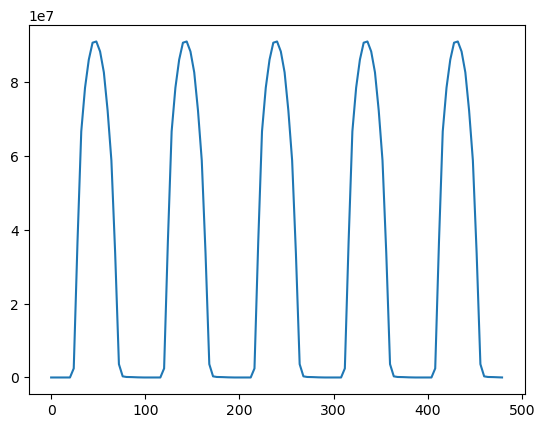

In [16]:
plt.plot(solar_mean_profile_aggregated)

In [17]:
try:
   #  print(f"\n--- Processando dados de Geração Eólica Reais (Média Agregada) do arquivo '{nome_do_arquivo_eolica}' ---")
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
   #  print(f"Perfil Eólico de Média Agregada: {len(wind_mean_profile_aggregated)} pontos.")
   #  print("Primeiros 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil eólico agregado (Watts):", max(wind_mean_profile_aggregated))
   #  print("Valor mínimo no perfil eólico agregado (Watts):", min(wind_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO EÓLICO: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit()

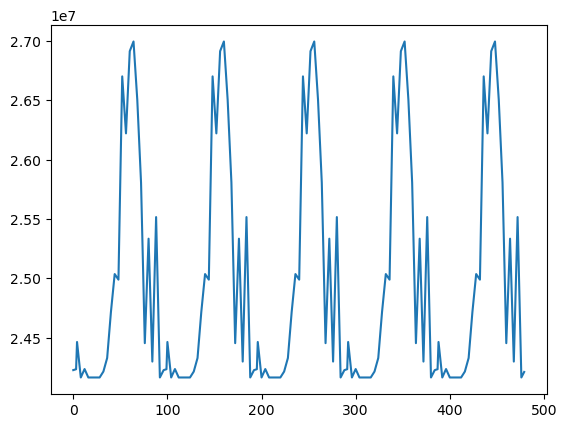

In [18]:
plt.plot(wind_mean_profile_aggregated)

In [19]:
h2_price_to_test = 30.00
ammonia_prices_to_test = [4.00, 5.50]

ammonia_price = ammonia_prices_to_test[0]

# Passamos os perfis de média agregada para solar e eólica para a função
all_scenario_profiles = load_and_process_scenario_data(
    N,
    INTERVALO_HORAS,
    LOAD_MAX_W,               # Carga máxima
    GEN_MAX_W,               # Geração Solar/Eólica máxima
    pld_data=pld_data_for_scenarios,
    solar_mean_profile=solar_mean_profile_aggregated,
    wind_mean_profile=wind_mean_profile_aggregated,
    fixed_h2_price=h2_price_to_test,
    fixed_ammonia_price=ammonia_price
)

#   print("\nIniciando a resolução do Modelo Estocástico...")
all_scenario_names = ["optimal", "good", "bad"]
options = {"solver": "cplex"}

creator_with_data = lambda scenario_name, **kwargs: scenario_creator(
    scenario_name, all_profiles=all_scenario_profiles, **kwargs
)

--- Construindo perfis: Preço H₂ (Venda) = R$ 30.00/kg | Preço Amônia (Venda) = R$ 4.00/kg ---


In [20]:
all_scenario_names

['optimal', 'good', 'bad']

In [21]:
all_scenario_profiles.keys()

dict_keys(['optimal', 'good', 'bad'])

In [22]:
all_scenario_profiles['optimal'].keys()

dict_keys(['wind_gen_w', 'solar_gen_w', 'spot_prices_mwh', 'load_w', 'h2_price_venda', 'ammonia_price_venda'])

In [23]:
creator_with_data('optimal')

In [24]:
options

{'solver': 'cplex'}

In [25]:
ef_builder = ExtensiveForm(options, all_scenario_names, creator_with_data)
solver = pyo.SolverFactory(options["solver"])
results = solver.solve(ef_builder.ef, tee=True)

if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
 #    print(f"\n--- Resultados da Otimização ---")
    ef_model = ef_builder.ef
    
    expected_profit = pyo.value(ef_model.EF_Obj)
    print(f"Valor Objetivo Ótimo (Lucro Esperado Total): R$ {expected_profit:,.2f}")
    
    first_block = getattr(ef_model, all_scenario_names[0])
    initial_socs = {
        'elec': pyo.value(first_block.X['ELEC_INITIAL_SOC']),
        'h2': pyo.value(first_block.X['H2_INITIAL_SOC']),
        'ammonia': pyo.value(first_block.X['AMMONIA_INITIAL_SOC'])
    }
  #   print("\nDecisões do Primeiro Estágio (aqui e agora):")
  #   print(f"  SOC Inicial Ótimo da BESS: {initial_socs['elec'] / 1e6:.2f} MWh")
  #   print(f"  SOC Inicial Ótimo do Tanque de H2: {initial_socs['h2']:.2f} kg")
   #  print(f"  SOC Inicial Ótimo do Tanque de Amônia: {initial_socs['ammonia']:.2f} kg")
    
   #  print("\nParâmetros Econômicos e de Conversão da Simulação:")
   #  print("-" * 50)
   #  print(f"  - Preço de Venda do H₂:       R$ {h2_price_to_test:.2f}/kg")
   #  print(f"  - Preço de Venda da Amônia:   R$ {ammonia_price:.2f}/kg")
    rendimento_h2_nh3 = 1 / TX_H2_TO_AMMONIA_KG_PER_KG
   #  print(f"  - Fator Haber-Bosch (Inverso): {rendimento_h2_nh3:.2f} kg de NH₃ gerados por kg de H₂")
   #  print("-" * 50)

[   17.34] Initializing SPBase

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.2.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2024.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmpl20dtmx6.cplex.log' open.
CPLEX> Problem '/tmp/tmp7ika6qw4.pyomo.lp' read.
Read time = 0.12 sec. (7.27 ticks)
CPLEX> Problem name         : /tmp/tmp7ika6qw4.pyomo.lp
Objective sense      : Maximize
Variables            :   33129  [Nneg: 10080,  Box: 14409,  Binary: 8640]
Objective nonzeros   :    1920
Linear constraints   :   43017  [Less: 30051,  Equal: 12966]
  Nonzeros           :  116262
  RHS nonzeros       :   22842

Variables            : Min LB: 0.000000         Max UB: 5.250000e+07   
Objective nonzeros   : Min   : 1.526750e-05     Max   : 1.0000

In [26]:
ef_model

In [27]:
getattr(ef_model, 'bad')

In [28]:
getattr(ef_model, 'good')

In [29]:
getattr(ef_model, 'optimal')

In [30]:
optimal_model = getattr(ef_model, 'optimal')

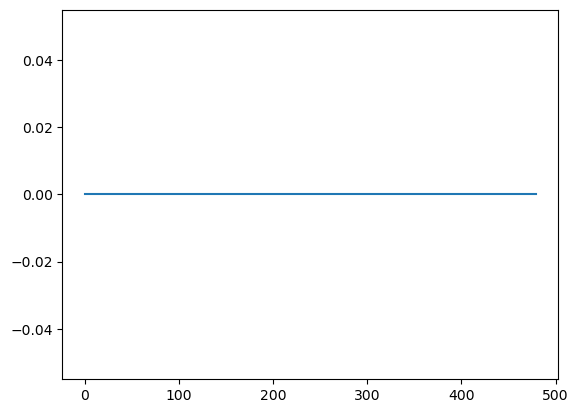

In [31]:
plt.plot(np.array([i.value for i in optimal_model.GRID_BUY_POWER.values()]))

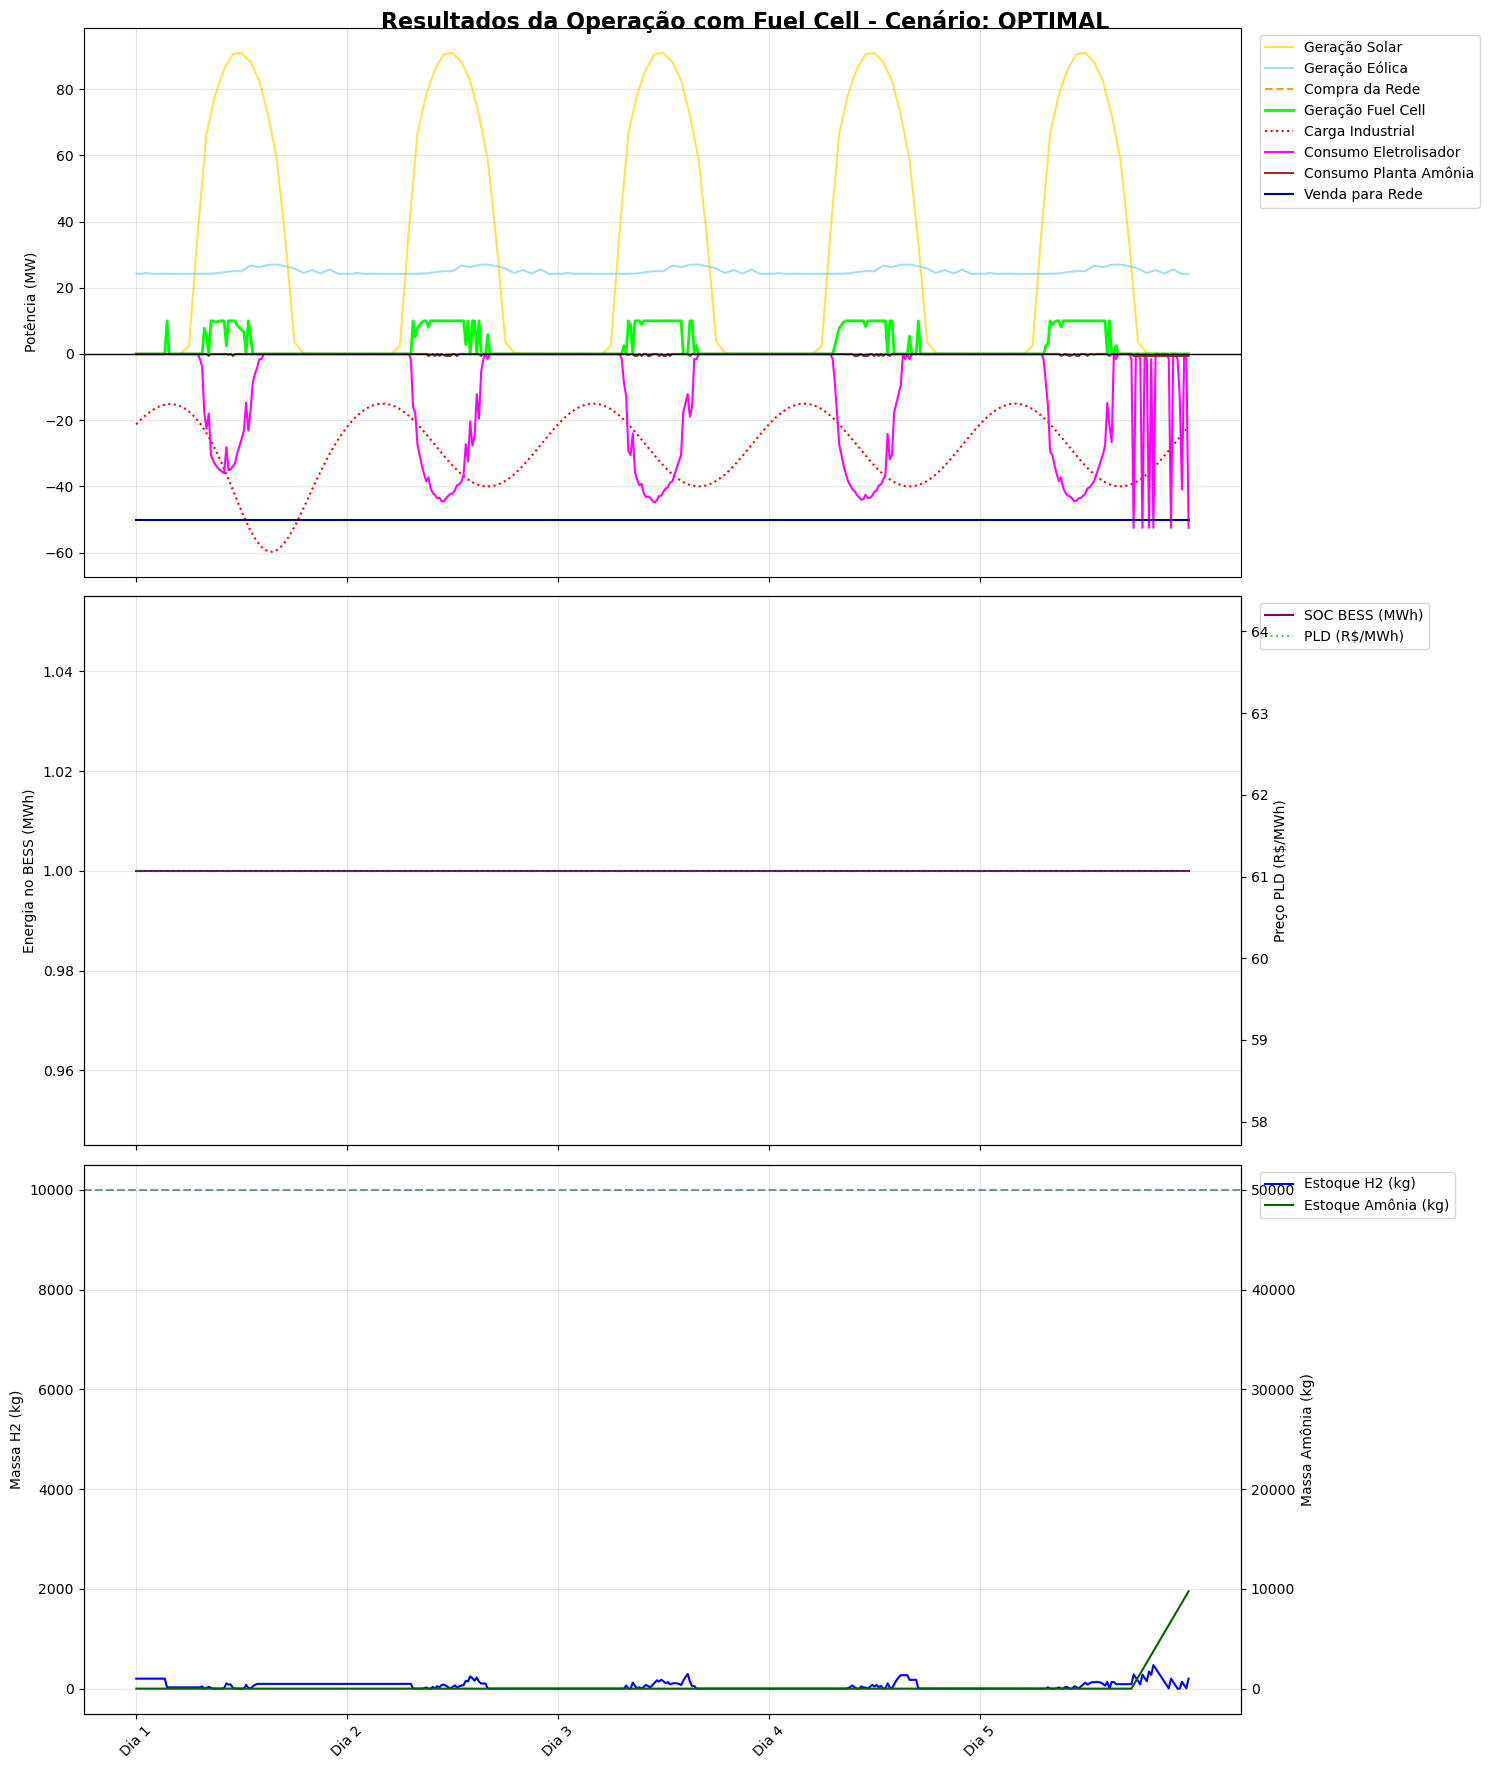

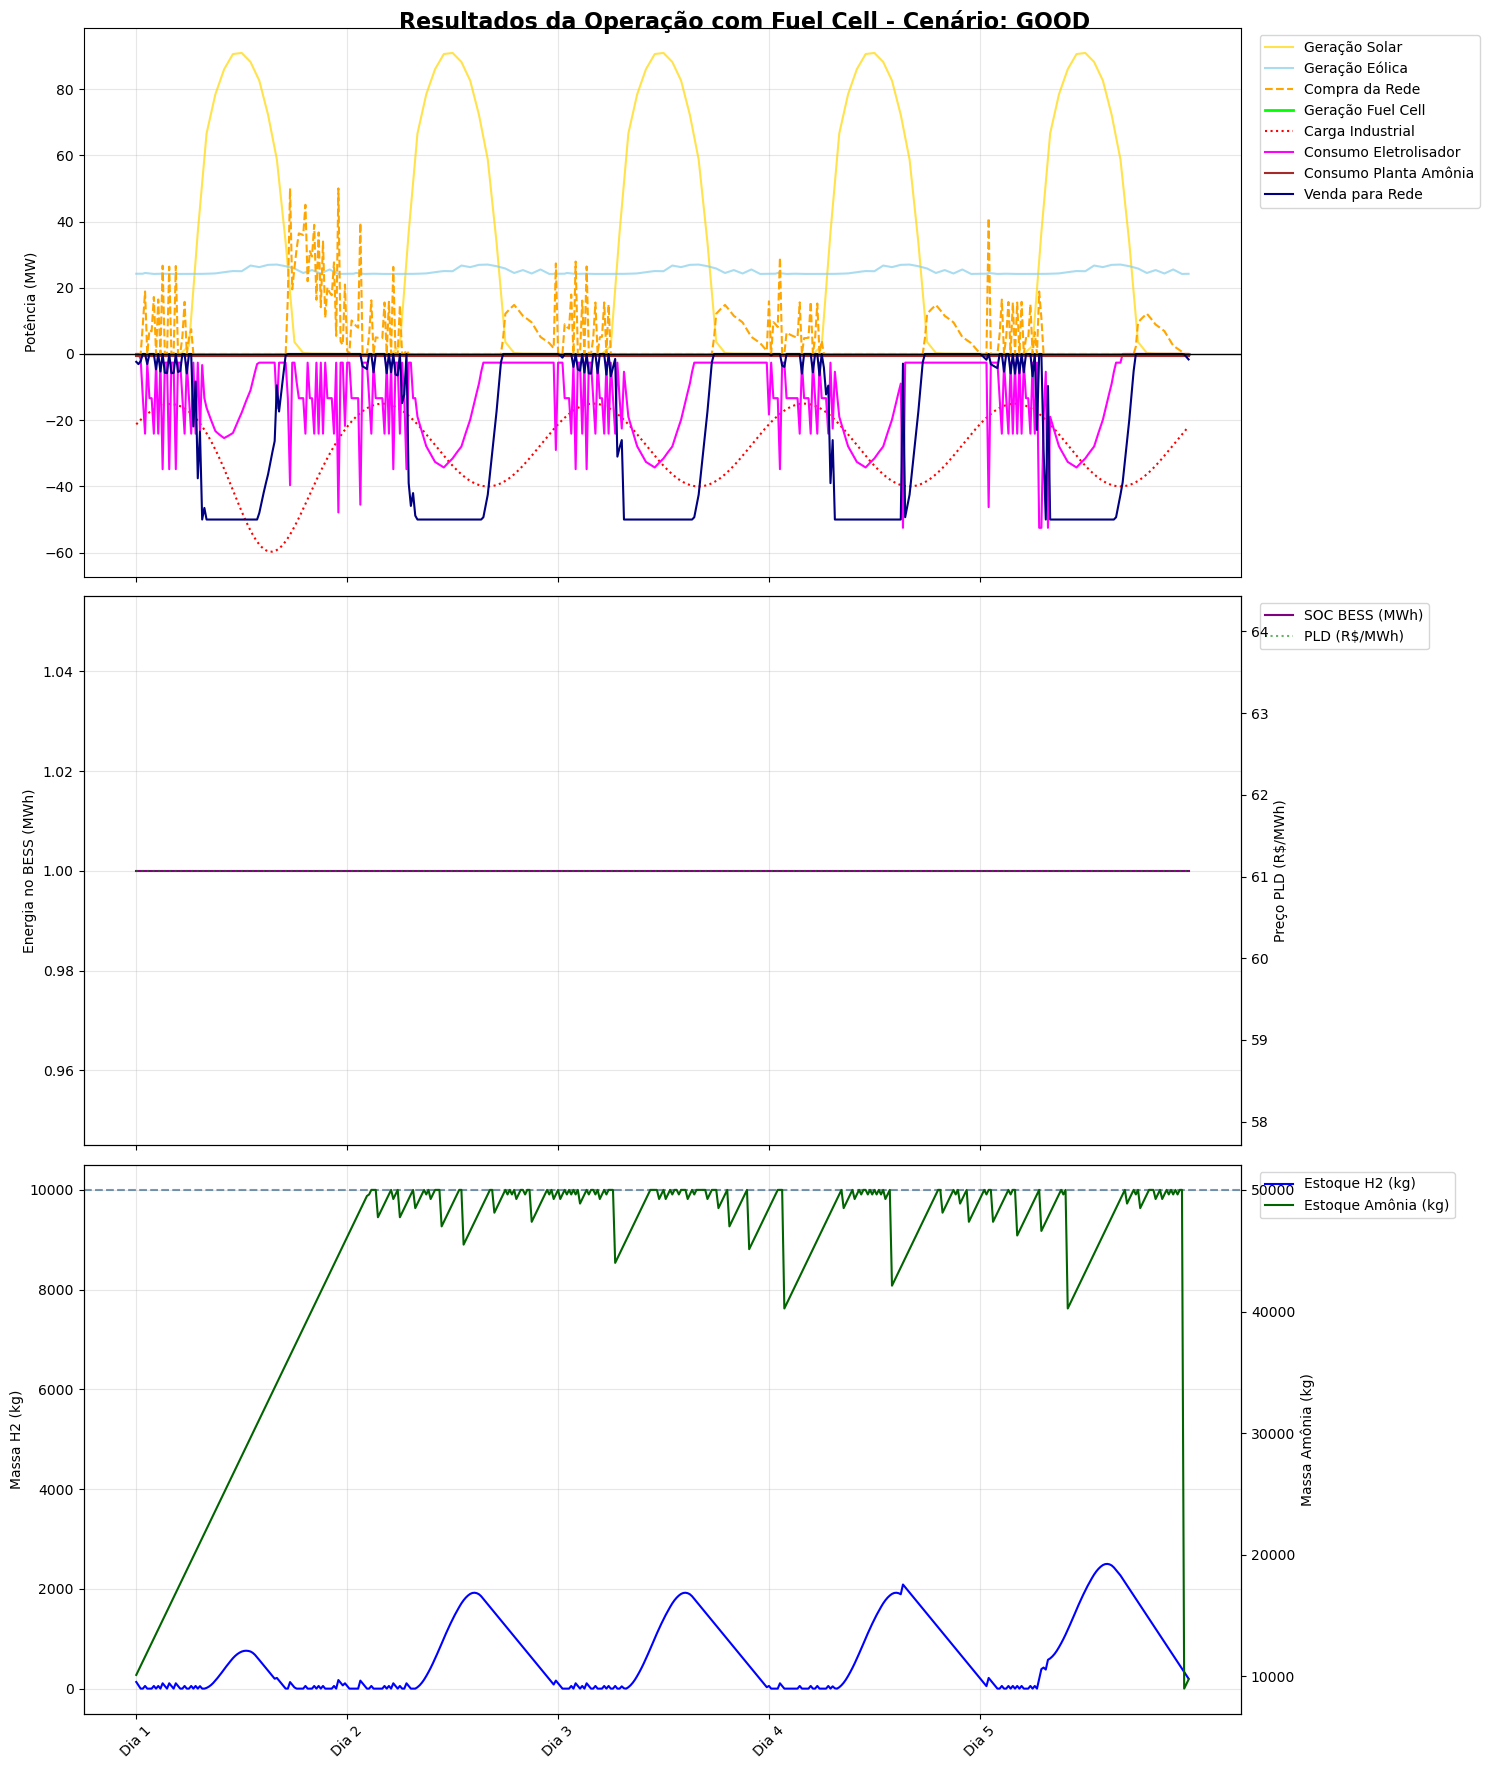

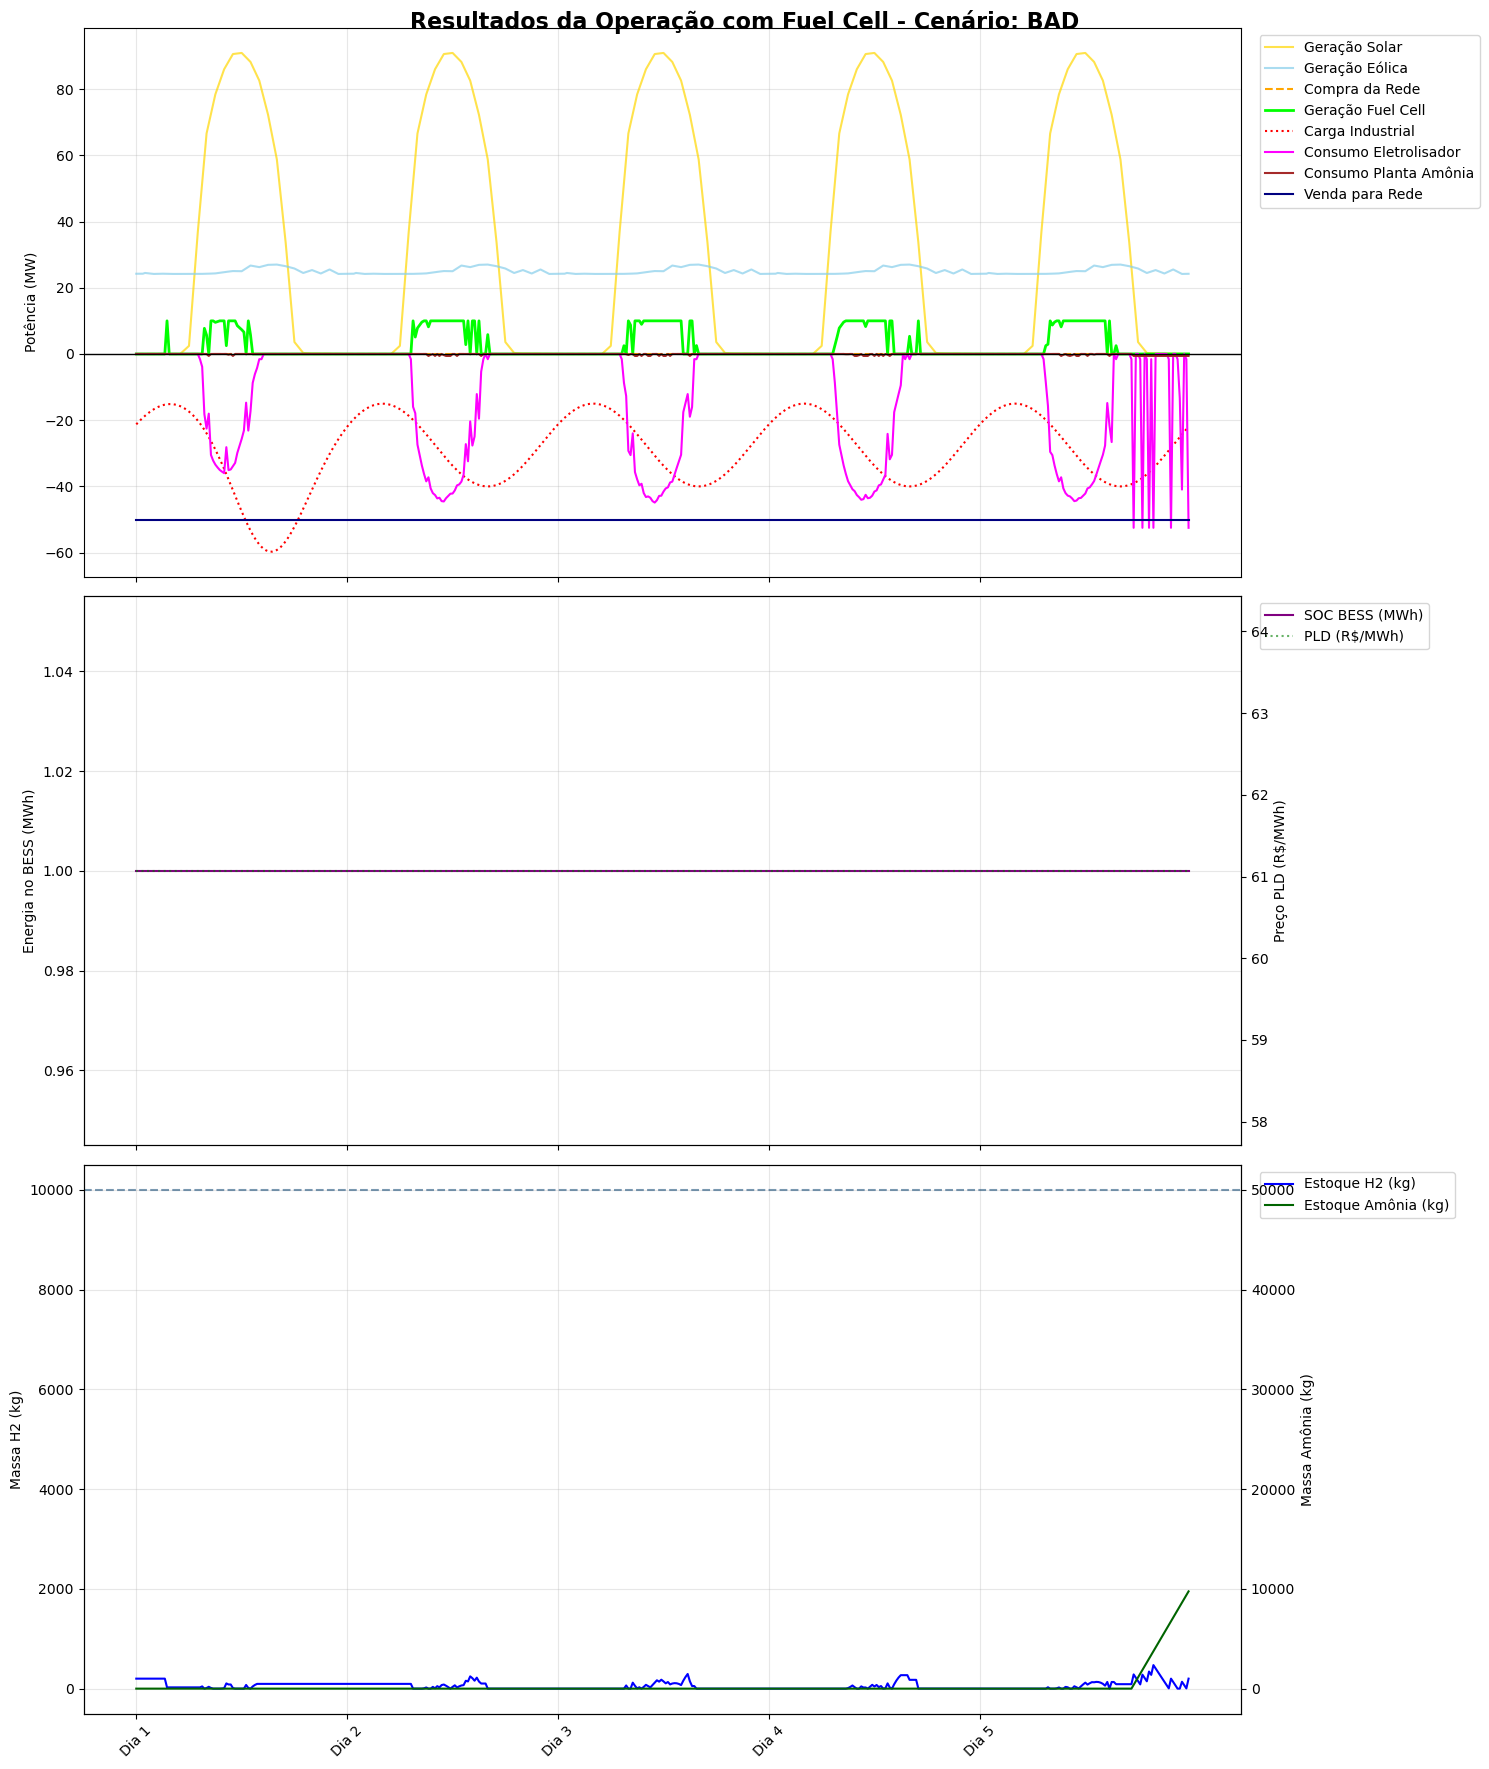

In [32]:
# --- Geração de Gráficos por Cenário ---
if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
    ef_model = ef_builder.ef
    
    # O TIME_HORIZON agora é um array de 1440 pontos
    for s_name in all_scenario_names:
        s_block = getattr(ef_model, s_name)
        
        plot_scenario_results(
            TIME_HORIZON,
            s_block, 
            s_name, 
            initial_socs, 
            fixed_h2_price=h2_price_to_test,
            fixed_ammonia_price=ammonia_price,
            AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG=AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG,
            INTERVALO_HORAS=INTERVALO_HORAS,
            N=N,
            h2_max_soc_kg=h2_max_soc_kg,
            h2_min_soc_kg=h2_min_soc_kg,
            ammonia_max_soc_kg=ammonia_max_soc_kg,
            ammonia_min_soc_kg=ammonia_min_soc_kg,
            TX_H2_TO_AMMONIA_KG_PER_KG=TX_H2_TO_AMMONIA_KG_PER_KG
        )
else:
    print(f"\nO solver não encontrou uma solução ótima. Condição: {results.solver.termination_condition}")

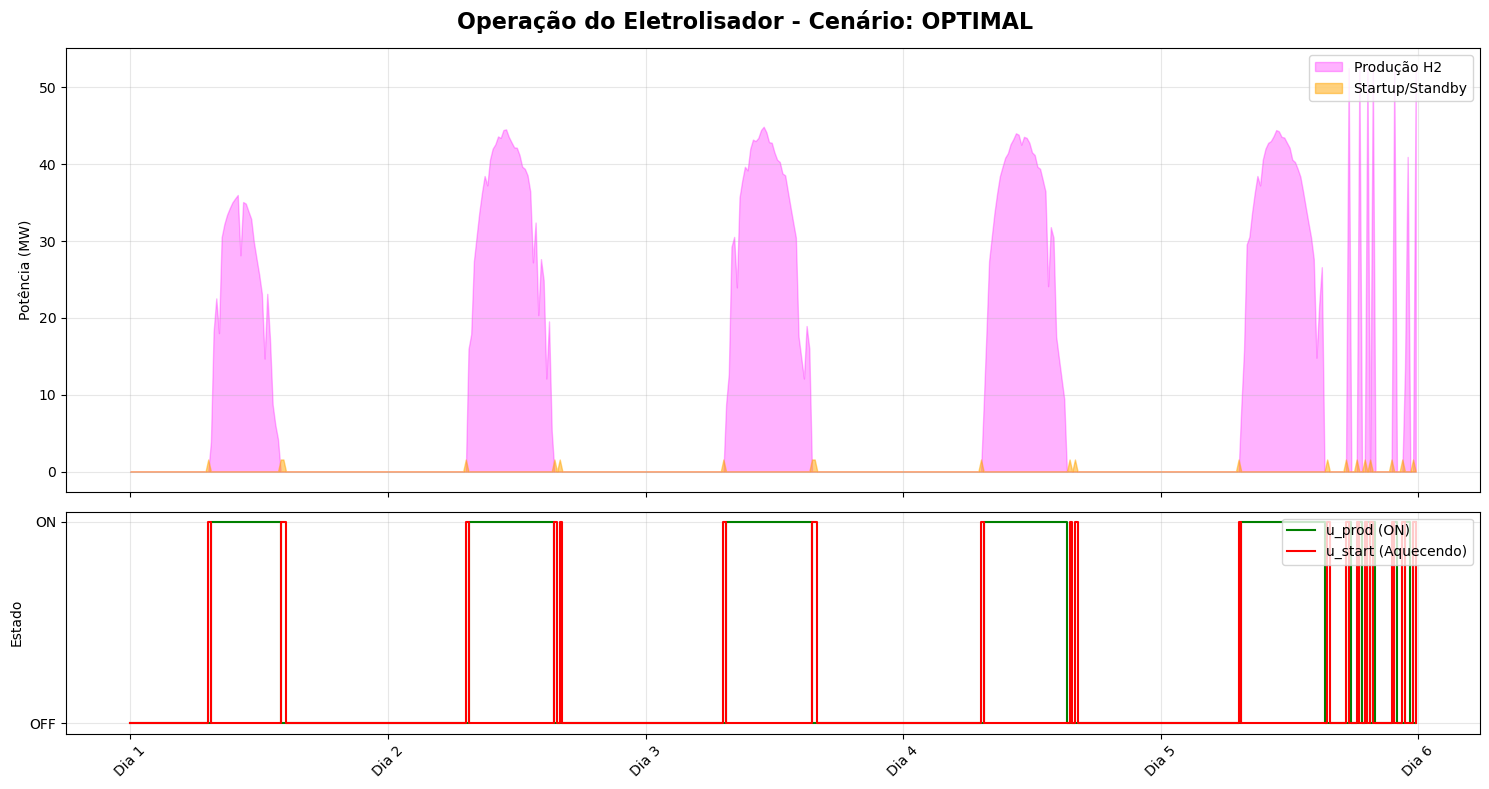

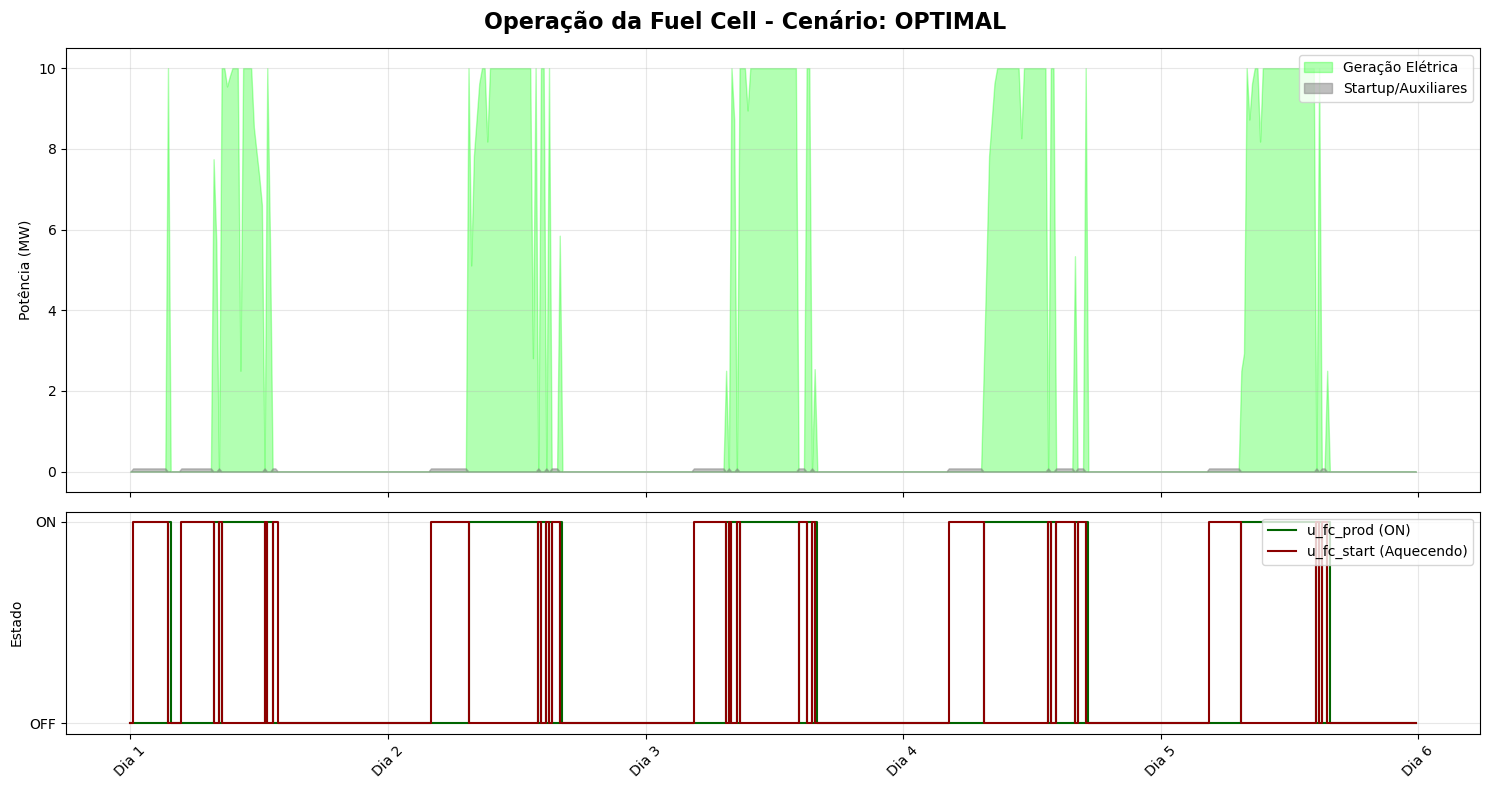

In [33]:


# Seleção do cenário para visualização
s_name = all_scenario_names[0]
s_block = getattr(ef_model, s_name)

# --- 1. EXTRAÇÃO DE DADOS: ELETROLISADOR ---
res_el_p_prod = np.array([pyo.value(s_block.P_PROD[t]) for t in TIME_HORIZON]) / 1e6
res_el_p_start = np.array([pyo.value(s_block.P_START[t]) for t in TIME_HORIZON]) / 1e6
res_el_u_prod = np.array([pyo.value(s_block.u_prod[t]) for t in TIME_HORIZON])
res_el_u_start = np.array([pyo.value(s_block.u_start[t]) for t in TIME_HORIZON])

# --- 2. EXTRAÇÃO DE DADOS: FUEL CELL ---
res_fc_p_gen = np.array([pyo.value(s_block.P_FC_GEN[t]) for t in TIME_HORIZON]) / 1e6
res_fc_p_start = np.array([pyo.value(s_block.P_FC_START[t]) for t in TIME_HORIZON]) / 1e6
res_fc_u_prod = np.array([pyo.value(s_block.u_fc_prod[t]) for t in TIME_HORIZON])
res_fc_u_start = np.array([pyo.value(s_block.u_fc_start[t]) for t in TIME_HORIZON])

# Configuração de tempo (Dias)
passos_por_dia = int(24 / INTERVALO_HORAS)
x_ticks = np.arange(0, len(TIME_HORIZON) + 1, passos_por_dia)
x_labels = [f"Dia {int(t/passos_por_dia) + 1}" for t in x_ticks]

# =================================================================
# GRÁFICO 1: ELETROLISADOR
# =================================================================
fig1, (ax1a, ax1b) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig1.suptitle(f'Operação do Eletrolisador - Cenário: {s_name.upper()}', fontsize=16, fontweight='bold')

ax1a.fill_between(TIME_HORIZON, res_el_p_prod, label='Produção H2', color='magenta', alpha=0.3)
ax1a.fill_between(TIME_HORIZON, res_el_p_start, label='Startup/Standby', color='orange', alpha=0.5)
ax1a.set_ylabel('Potência (MW)')
ax1a.legend(loc='upper right')
ax1a.grid(True, alpha=0.3)

ax1b.step(TIME_HORIZON, res_el_u_prod, label='u_prod (ON)', color='green', where='post')
ax1b.step(TIME_HORIZON, res_el_u_start, label='u_start (Aquecendo)', color='red', where='post')
ax1b.set_ylabel('Estado')
ax1b.set_yticks([0, 1])
ax1b.set_yticklabels(['OFF', 'ON'])
ax1b.set_xticks(x_ticks)
ax1b.set_xticklabels(x_labels, rotation=45)
ax1b.legend(loc='upper right')
ax1b.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================
# GRÁFICO 2: FUEL CELL
# =================================================================
fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig2.suptitle(f'Operação da Fuel Cell - Cenário: {s_name.upper()}', fontsize=16, fontweight='bold')

ax2a.fill_between(TIME_HORIZON, res_fc_p_gen, label='Geração Elétrica', color='lime', alpha=0.3)
ax2a.fill_between(TIME_HORIZON, res_fc_p_start, label='Startup/Auxiliares', color='grey', alpha=0.5)
ax2a.set_ylabel('Potência (MW)')
ax2a.legend(loc='upper right')
ax2a.grid(True, alpha=0.3)

ax2b.step(TIME_HORIZON, res_fc_u_prod, label='u_fc_prod (ON)', color='darkgreen', where='post')
ax2b.step(TIME_HORIZON, res_fc_u_start, label='u_fc_start (Aquecendo)', color='darkred', where='post')
ax2b.set_ylabel('Estado')
ax2b.set_yticks([0, 1])
ax2b.set_yticklabels(['OFF', 'ON'])
ax2b.set_xticks(x_ticks)
ax2b.set_xticklabels(x_labels, rotation=45)
ax2b.legend(loc='upper right')
ax2b.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

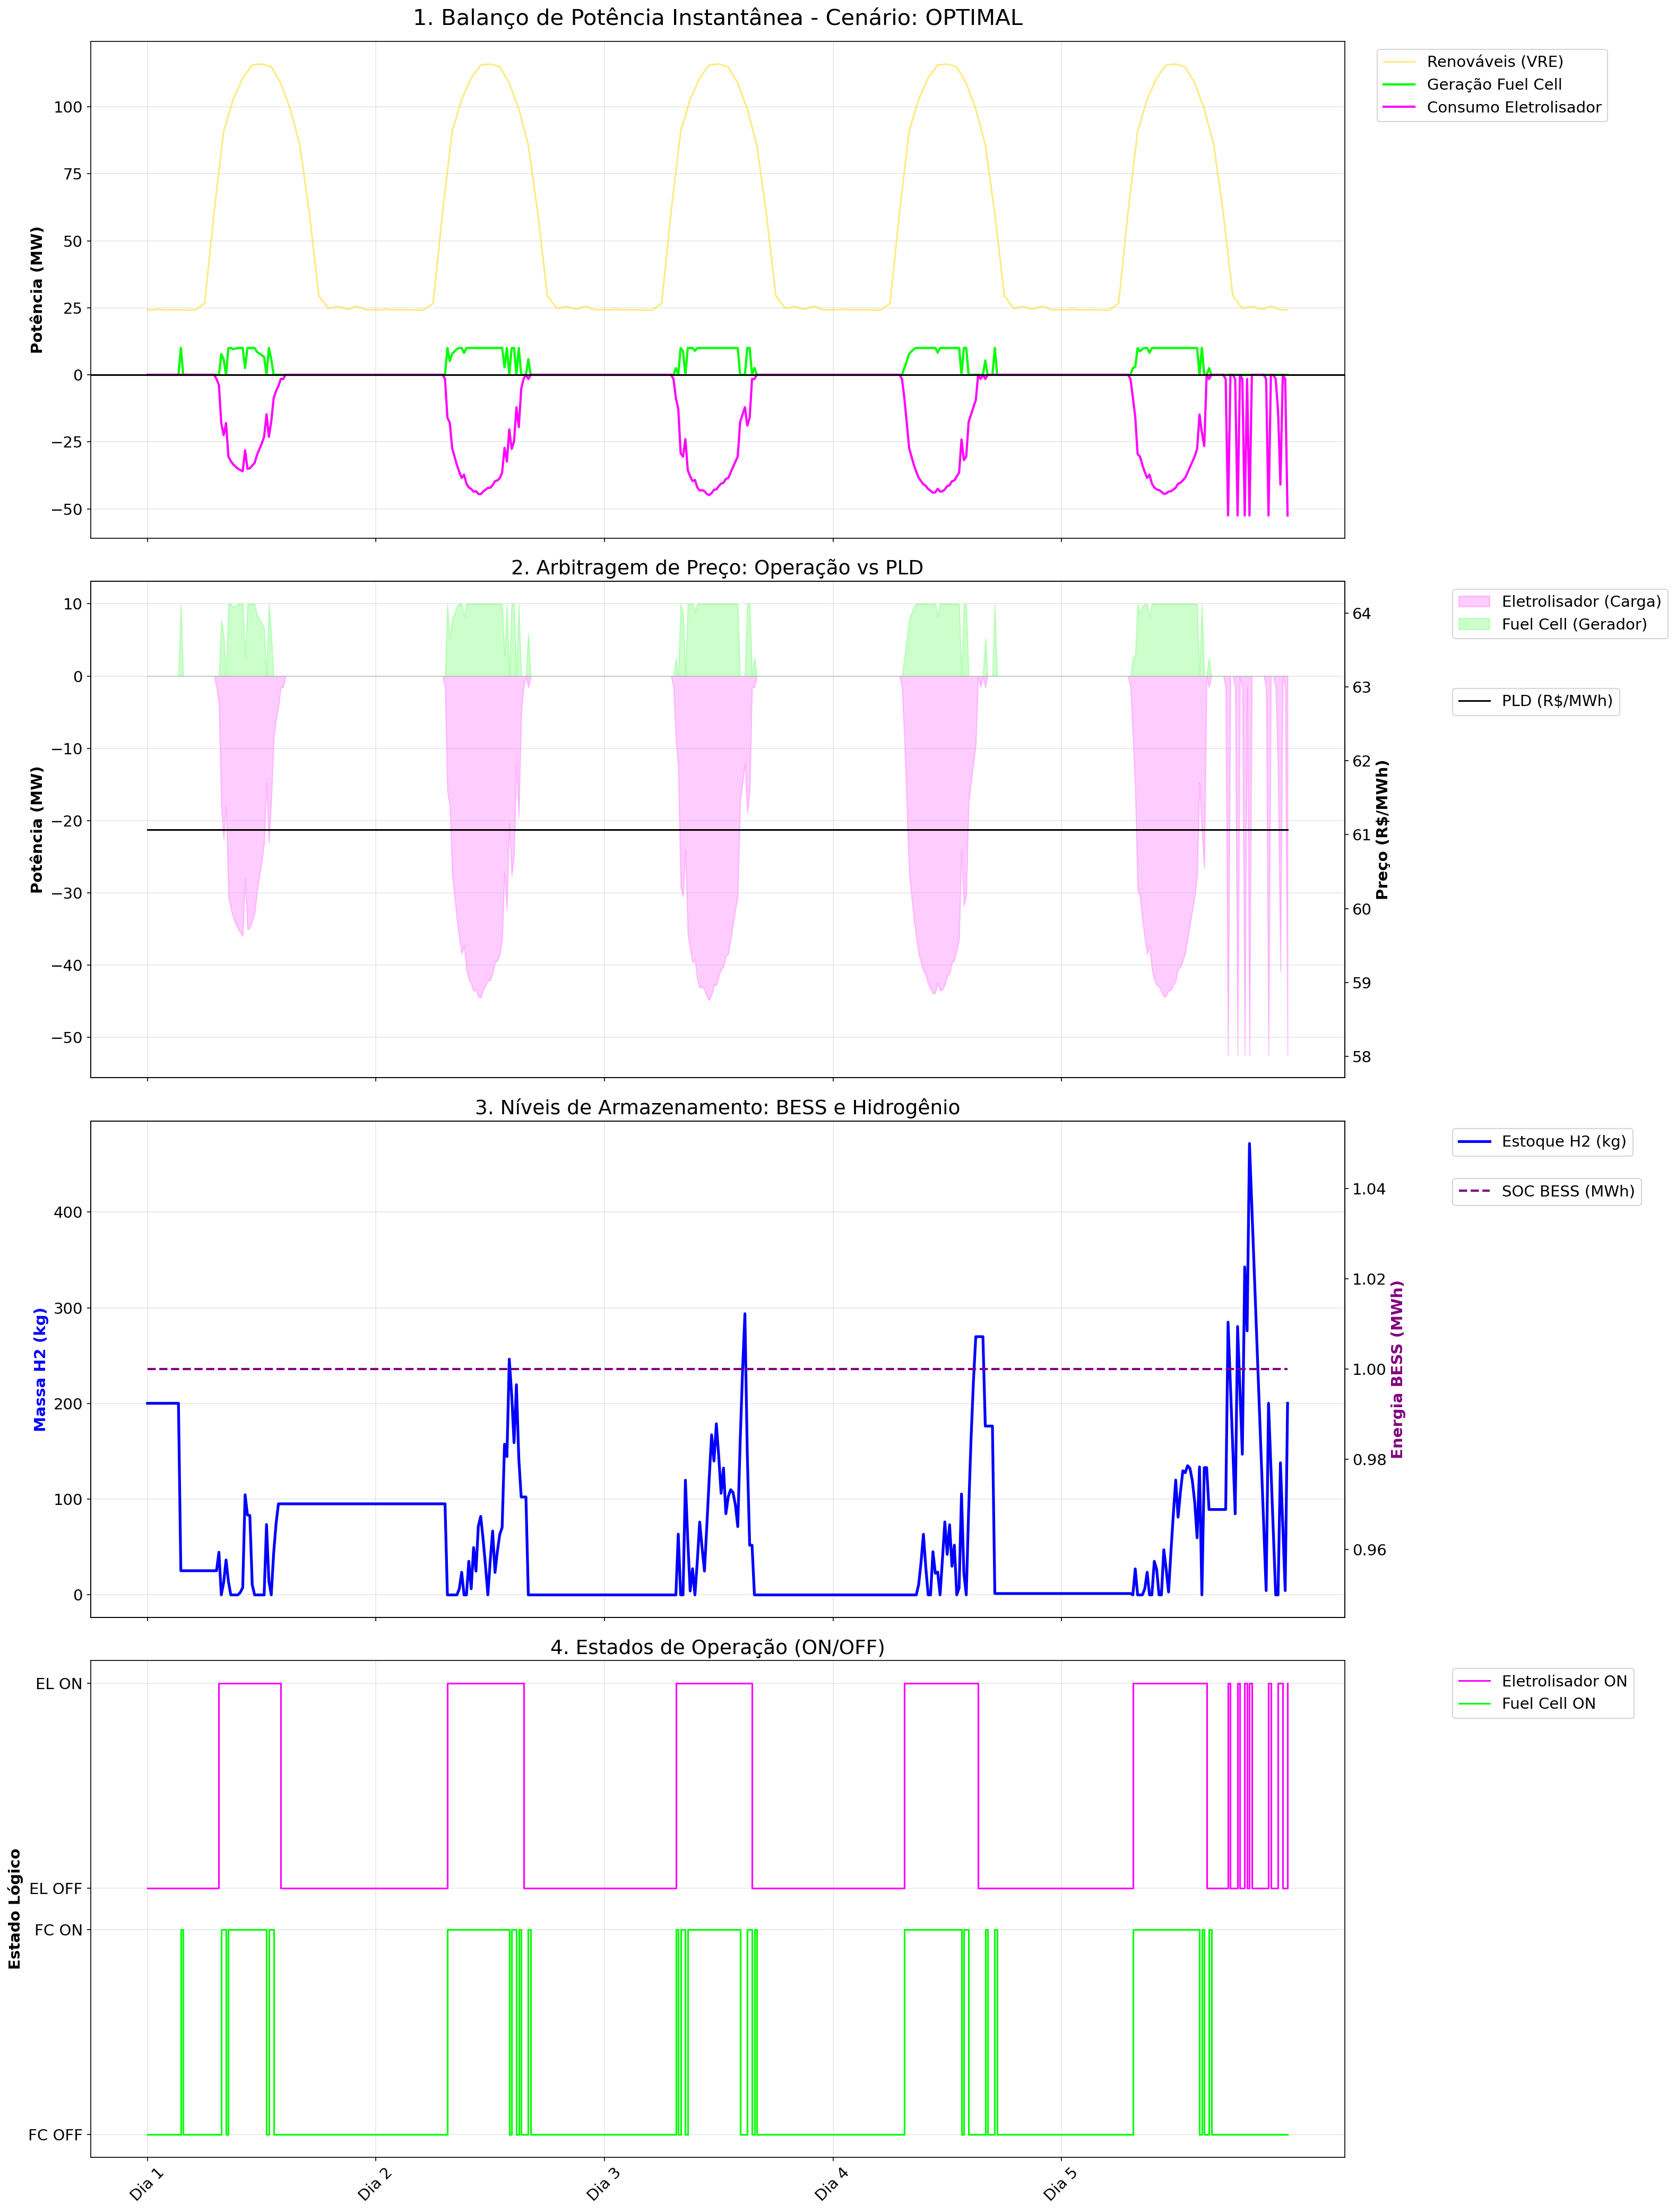

In [34]:

    # --- 1. EXTRAÇÃO E TRATAMENTO ---
    pld = np.array([pyo.value(s_block.price[t]) for t in TIME_HORIZON]) * 1e6
    p_el = np.array([pyo.value(s_block.P_PROD[t] + s_block.P_START[t]) for t in TIME_HORIZON]) / 1e6
    p_fc = np.array([pyo.value(s_block.P_FC_GEN[t]) for t in TIME_HORIZON]) / 1e6
    res_solar = np.array([pyo.value(s_block.p_solar[t]) for t in TIME_HORIZON]) / 1e6
    res_wind = np.array([pyo.value(s_block.p_wind[t]) for t in TIME_HORIZON]) / 1e6
    
    soc_h2 = np.array([pyo.value(s_block.H2_STORAGE_SOC[t]) for t in TIME_HORIZON])
    soc_bess = np.array([pyo.value(s_block.BESS_SOC[t]) for t in TIME_HORIZON]) / 1e6
    
    u_el = np.array([pyo.value(s_block.u_prod[t]) for t in TIME_HORIZON])
    u_fc = np.array([pyo.value(s_block.u_fc_prod[t]) for t in TIME_HORIZON])

    # Configuração de Tempo (7 Dias)
    passos_por_dia = int(24 / INTERVALO_HORAS)
    x_ticks = np.arange(0, len(TIME_HORIZON), passos_por_dia)
    x_labels = [f"Dia {int(t/passos_por_dia) + 1}" for t in x_ticks]

    # --- 2. ESTILO GLOBAL ---
    plt.rcParams.update({'font.size': 14, 'axes.labelweight': 'bold', 'figure.dpi': 150})
    fig, axes = plt.subplots(4, 1, figsize=(20, 28), sharex=True)
    
    # --- GRÁFICO 1: BALANÇO DE POTÊNCIA (INTEGRAÇÃO SISTÊMICA) ---
    ax1 = axes[0]
    ax1.set_title(f'1. Balanço de Potência Instantânea - Cenário: {s_name.upper()}', fontsize=20, pad=15)
    ax1.plot(TIME_HORIZON, res_solar + res_wind, label='Renováveis (VRE)', color='gold', alpha=0.5)
    ax1.plot(TIME_HORIZON, p_fc, label='Geração Fuel Cell', color='lime', linewidth=2)
    ax1.plot(TIME_HORIZON, -p_el, label='Consumo Eletrolisador', color='magenta', linewidth=2)
    ax1.axhline(0, color='black', lw=1.5)
    ax1.set_ylabel('Potência (MW)')
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax1.grid(True, alpha=0.3)

    # --- GRÁFICO 2: ARBITRAGEM DE PREÇO (DESPACHO ECONÔMICO) ---
    ax2 = axes[1]
    ax2.set_title('2. Arbitragem de Preço: Operação vs PLD', fontsize=18)
    ax2.fill_between(TIME_HORIZON, -p_el, color='magenta', alpha=0.2, label='Eletrolisador (Carga)')
    ax2.fill_between(TIME_HORIZON, p_fc, color='lime', alpha=0.2, label='Fuel Cell (Gerador)')
    ax2_pld = ax2.twinx()
    ax2_pld.plot(TIME_HORIZON, pld, color='black', lw=1.5, label='PLD (R$/MWh)')
    ax2.set_ylabel('Potência (MW)')
    ax2_pld.set_ylabel('Preço (R$/MWh)')
    ax2.legend(loc='upper left', bbox_to_anchor=(1.08, 1))
    ax2_pld.legend(loc='upper left', bbox_to_anchor=(1.08, 0.8))
    ax2.grid(True, alpha=0.3)

    # --- GRÁFICO 3: DINÂMICA DE ARMAZENAMENTO (AUTONOMIA) ---
    ax3 = axes[2]
    ax3.set_title('3. Níveis de Armazenamento: BESS e Hidrogênio', fontsize=18)
    ax3.plot(TIME_HORIZON, soc_h2, color='blue', lw=2.5, label='Estoque H2 (kg)')
    ax3_bess = ax3.twinx()
    ax3_bess.plot(TIME_HORIZON, soc_bess, color='purple', lw=2, linestyle='--', label='SOC BESS (MWh)')
    ax3.set_ylabel('Massa H2 (kg)', color='blue')
    ax3_bess.set_ylabel('Energia BESS (MWh)', color='purple')
    ax3.legend(loc='upper left', bbox_to_anchor=(1.08, 1))
    ax3_bess.legend(loc='upper left', bbox_to_anchor=(1.08, 0.9))
    ax3.grid(True, alpha=0.3)

    # --- GRÁFICO 4: ESTADOS OPERACIONAIS (BINÁRIAS) ---
    ax4 = axes[3]
    ax4.set_title('4. Estados de Operação (ON/OFF)', fontsize=18)
    ax4.step(TIME_HORIZON, u_el, color='magenta', where='post', label='Eletrolisador ON')
    ax4.step(TIME_HORIZON, u_fc - 1.2, color='lime', where='post', label='Fuel Cell ON') # Offset para não sobrepor
    ax4.set_yticks([1, 0, -0.2, -1.2])
    ax4.set_yticklabels(['EL ON', 'EL OFF', 'FC ON', 'FC OFF'])
    ax4.set_xticks(x_ticks)
    ax4.set_xticklabels(x_labels, rotation=45)
    ax4.set_ylabel('Estado Lógico')
    ax4.legend(loc='upper left', bbox_to_anchor=(1.08, 1))
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()